# Notebook to Train Plushie Classifier

In [1]:
import matplotlib.pyplot as plt
# import numpy as np
import PIL
import pathlib

## TensorFlow

### Setup

Importing tensorflow libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

Get the images from `/images`

In [3]:
parent_dir = pathlib.Path.cwd().parent
data_dir = parent_dir / "images"
image_count = len(list(data_dir.glob("*/*.jpg")))
image_count

6927

The number of images per animal.

In [4]:
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        count = len(list(folder.glob("*.jpg")))
        print(f"{folder.name}: {count}")

bear: 427
cat: 397
crab: 246
dog: 420
dolphin: 328
elephant: 400
fox: 402
koala: 384
lion: 419
octopus: 303
panda: 402
rabbit: 441
sea_turtle: 289
shark: 307
shrimp: 250
snake: 407
squid: 282
tiger: 394
whale: 429


Here are pictures of some of the plushes:

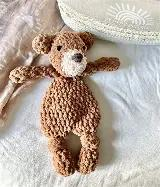

In [5]:
bear_plushes = list(data_dir.glob("bear/*.jpg"))
PIL.Image.open(bear_plushes[0])

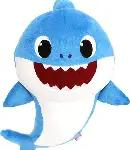

In [6]:
shark_plushes = list(data_dir.glob("shark/*.jpg"))
PIL.Image.open(shark_plushes[0])

### Handling the Data

Defining parameters for the loader:

In [7]:
batch_size = 32
IMG_SIZE = 128

Get the training and validation sets. Split 80% for training and 20% for validation.

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  image_size=(IMG_SIZE, IMG_SIZE),
  validation_split=0.2,
  subset="training",
  seed=999,
  batch_size=batch_size,
)

Found 6927 files belonging to 19 classes.
Using 5542 files for training.


In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  image_size=(IMG_SIZE, IMG_SIZE),
  validation_split=0.2,
  subset="validation",
  seed=999,
  batch_size=batch_size
)

Found 6927 files belonging to 19 classes.
Using 1385 files for validation.


Double check the class names fit with each animal type.

In [10]:
class_names = train_ds.class_names
class_names

['bear',
 'cat',
 'crab',
 'dog',
 'dolphin',
 'elephant',
 'fox',
 'koala',
 'lion',
 'octopus',
 'panda',
 'rabbit',
 'sea_turtle',
 'shark',
 'shrimp',
 'snake',
 'squid',
 'tiger',
 'whale']

#### Visualizing the Data

2026-02-20 21:12:42.893865: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


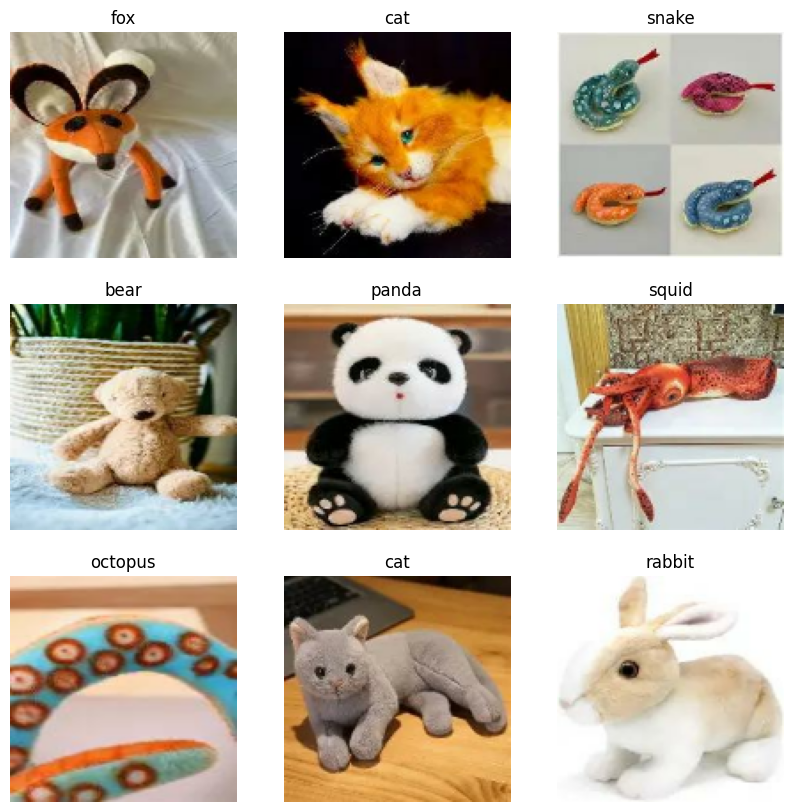

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

#### Reconfiguring the Data for Performance

Use `Dataset.cache()` and `Dataset.prefetch()` to keep data in memory, and make sure I/O is non-blocking.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Creating and Training the Model

Define a basic Keras model:

In [13]:
num_classes = len(class_names)

model = Sequential([
  layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

In [14]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,123,315 (8.10 MB)

 Trainable params: 2,123,315 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

Training the model:

In [15]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.2043 - loss: 2.5786 - val_accuracy: 0.3242 - val_loss: 2.2631
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.4215 - loss: 1.9416 - val_accuracy: 0.4787 - val_loss: 1.7975
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6045 - loss: 1.3532 - val_accuracy: 0.5682 - val_loss: 1.5807
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.7584 - loss: 0.8497 - val_accuracy: 0.6433 - val_loss: 1.4602
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8668 - loss: 0.4770 - val_accuracy: 0.6765 - val_loss: 1.5418
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9244 - loss: 0.2673 - val_accuracy: 0.6693 - val_loss: 1.7621
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9558 - loss: 0.1578 - val_accuracy: 0.6903 - val_loss: 1.9999
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9691 - loss: 0.1147 - 

#### Visualizing the Training Process

In [16]:
def plot_history(history, max_epochs=None):
    # Handles EarlyStopping: use the actual history length.
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = min(len(acc), len(val_acc), len(loss), len(val_loss))
    if max_epochs is not None:
        epochs = min(epochs, int(max_epochs))
    if epochs == 0:
        raise ValueError('History is empty; nothing to plot')

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc[:epochs], label='Training Accuracy')
    plt.plot(epochs_range, val_acc[:epochs], label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss[:epochs], label='Training Loss')
    plt.plot(epochs_range, val_loss[:epochs], label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()


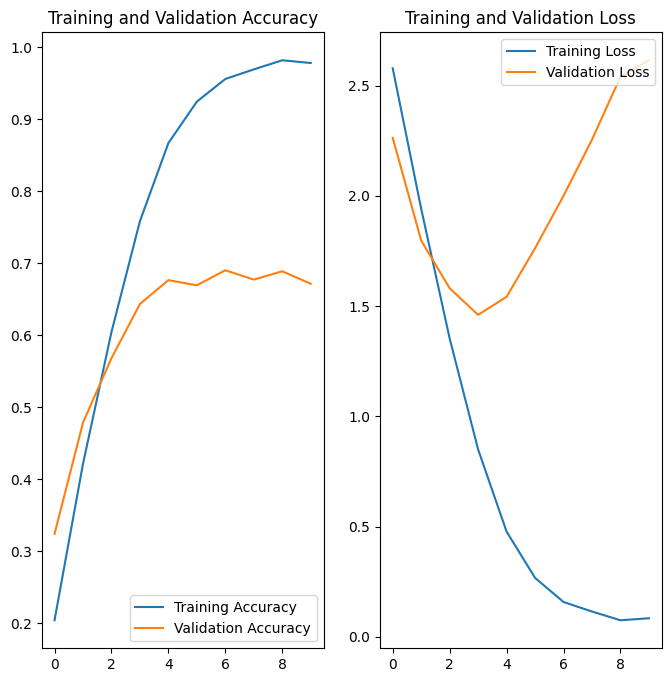

In [17]:
plot_history(history)

### Evaluating and Improving the Model

We can see from the high training accuracy and lower validation accuracy, the models suffer from overfitting. 

Because of our small sample size, we will use data augmentation to make sure the model does not account for specific features.

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

One other way to prevent overfitting is to add dropout layer to our model.
Another improvement to the training process is to add batch normalization to regularize.

We redefining our model to account for these changes:

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [20]:
model = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    # Preprocessing
    data_augmentation,
    layers.Rescaling(1./255),
    
    # Conv block 1
    layers.Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(), # Normalize the data
    layers.ReLU(),
    layers.MaxPooling2D(),
    
    # Conv block 2
    layers.Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(), # Normalize the data
    layers.ReLU(),
    layers.MaxPooling2D(),
    
    # Conv block 3
    layers.Conv2D(128, 3, padding='same', use_bias=False),
    layers.BatchNormalization(), # Normalize the data
    layers.ReLU(),
    layers.MaxPooling2D(),

    # Conv block 4
    layers.Conv2D(256, 3, padding='same', use_bias=False),
    layers.BatchNormalization(), # Normalize the data
    layers.ReLU(),
    layers.MaxPooling2D(),
    
    layers.GlobalAveragePooling2D(), # Switched from Flatten to reduce parameters
    
    layers.Dense(256, use_bias=False),
    layers.BatchNormalization(), # Normalize the data
    layers.ReLU(),
    layers.Dropout(0.2), # Dropout to prevent overfitting
    
    layers.Dense(num_classes, name="outputs")
])

We also define callbacks for early stopping, learning rate scheduling and model checkpointing. These will help our model train appropriately to maximize both training and validation accuracy.

In [21]:
callbacks = [
    # Early stopping to stop training when the validation accuracy stops improving
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Learning rate scheduling to prevent the model from overfitting
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
    # Model checkpointing to save the best model
    ModelCheckpoint(
        parent_dir / "models" / "tf_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [22]:
model.compile(
  optimizer=Adam(learning_rate=1e-3),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 256)            │             

 Total params: 461,299 (1.76 MB)

 Trainable params: 459,827 (1.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

Training our new model:

In [23]:
epochs = 50 # More epochs
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=callbacks
)

Epoch 1/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.1820 - loss: 2.7704
Epoch 1: val_accuracy improved from None to 0.05921, saving model to /Users/ADMIN/Desktop/Coding/plush_classifier/models/tf_model.keras

Epoch 1: finished saving model to /Users/ADMIN/Desktop/Coding/plush_classifier/models/tf_model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 46s 256ms/step - accuracy: 0.2286 - loss: 2.5426 - val_accuracy: 0.0592 - val_loss: 3.5966 - learning_rate: 0.0010
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.3033 - loss: 2.2267
Epoch 2: val_accuracy improved from 0.05921 to 0.09025, saving model to /Users/ADMIN/Desktop/Coding/plush_classifier/models/tf_model.keras

Epoch 2: finished saving model to /Users/ADMIN/Desktop/Coding/plush_classifier/models/tf_model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 43s 250ms/step - accuracy: 0.3160 - loss: 2.2123 - val_accuracy: 0.0903 - val_loss: 3.1121 - learning_rate: 0.0010
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - a

Revisualize our new model's results

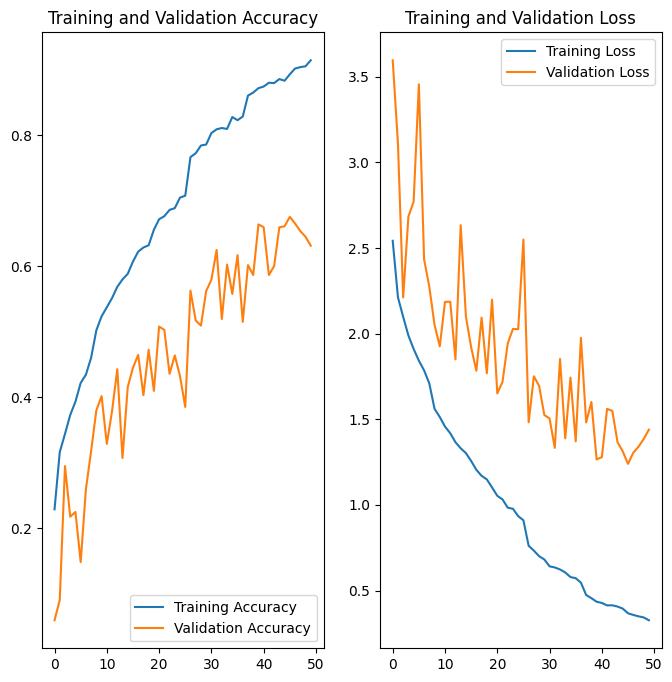

In [24]:
plot_history(history)